# Plot cloud fraction
- This script is used to visualize cloud fraction, downward solar radiation, and rural ground temperature.
- Simulations: CNTL, TranAlbe

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from scipy import stats
import string
from scipy.stats import gaussian_kde
import os
import matplotlib as mpl
home_path = '/gws/ssde/j25a/duicv/yuansun/'
project_path = f'{home_path}0_wrf-cstm_GM-HK/'

In [2]:
ds_mask_hk = xr.open_dataset(f'{project_path}HK/mask/mask_HK_lat_lon.nc')
ds_mask_hk

<xarray.Dataset> Size: 33kB
Dimensions:    (lat: 60, lon: 60)
Coordinates:
  * lat        (lat) float64 480B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
  * lon        (lon) float64 480B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
Data variables:
    mask       (lat, lon) bool 4kB ...
    PCT_URBAN  (lat, lon) float64 29kB ...

In [3]:
mask_hk = ds_mask_hk['mask']
mask_hk

<xarray.DataArray 'mask' (lat: 60, lon: 60)> Size: 4kB
[3600 values with dtype=bool]
Coordinates:
  * lat      (lat) float64 480B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
  * lon      (lon) float64 480B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5

In [4]:
ds_fsds = xr.open_dataset(f'./data_for_figure/changes_FSDS_2039_JJA.nc')
ds_tg_r = xr.open_dataset(f'./data_for_figure/changes_TG_R_2039_JJA.nc')
ds_tg_r_p_value = xr.open_dataset(f'./data_for_figure/changes_TG_R_2039_JJA_significance.nc')
ds_cloud = xr.open_dataset(f'./data_for_figure/changes_CLDFRA_2039_JJA.nc')
ds_cloud = ds_cloud.rename({'south_north': 'lat', 'west_east': 'lon'})
ds_cloud = ds_cloud.assign_coords(lon=ds_tg_r.lon.values, lat=ds_tg_r.lat.values)
ds_cloud

<xarray.Dataset> Size: 15kB
Dimensions:  (lat: 60, lon: 60)
Coordinates:
  * lon      (lon) float32 240B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
  * lat      (lat) float32 240B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
Data variables:
    CLDFRA   (lat, lon) float32 14kB ...

In [5]:
ds_cloud_p_value = xr.open_dataset(f'./data_for_figure/changes_CLDFRA_2039_JJA_significance.nc')
ds_cloud_p_value = ds_cloud_p_value.rename({'south_north': 'lat', 'west_east': 'lon'})
ds_cloud_p_value = ds_cloud_p_value.assign_coords(lon=ds_tg_r.lon.values, lat=ds_tg_r.lat.values)
ds_cloud_p_value

<xarray.Dataset> Size: 29kB
Dimensions:  (lat: 60, lon: 60)
Coordinates:
  * lon      (lon) float32 240B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
  * lat      (lat) float32 240B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
Data variables:
    CLDFRA   (lat, lon) float64 29kB ...

In [8]:
gpd_hk = gpd.read_file(f'{home_path}0_wrf-cstm_GM-HK/HK/mask/boundary/hk_boundary.shp')
gdp_hk = gpd_hk.to_crs(epsg=4326)
lat = ds_cloud.lat.values
lon = ds_cloud.lon.values
labelcolor = '#6b6b6b'
boundarywidth = 0.5
labelsize = 6
tick_length = 4
ticklabel_pad = 0.2
labelbottom = True
extent = [lon.min().item(), lon.max().item(), lat.min().item(), lat.max().item()] 
proj = ccrs.PlateCarree()
fontsize = 6
cbar_pad = -0.1  
linewidth = 0.5
title_list = [r'$\Delta f_\mathrm{cloud}$ VS $\Delta SW_\mathrm{down}$',
              r'$\Delta f_\mathrm{cloud}$', 
              r'$\Delta$TG_R']
padding = 4

Slope = -2226.044
Pearson r = -0.45, p = 8.06e-50


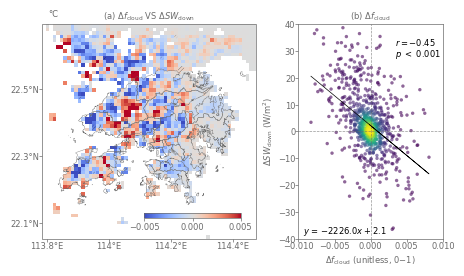

In [18]:
fig = plt.figure(figsize=(4.5, 2.65))
gs_outer = gridspec.GridSpec(
    nrows=1,
    ncols=2,
    width_ratios=[1, 0.6],  # 1.3 + 1.3 = 2.6
    wspace=0.15
)

ax0 = fig.add_subplot(gs_outer[0, 0], projection=proj)
#ax  = fig.add_subplot(gs_left[0, 1], projection=proj)
ax1 = fig.add_subplot(gs_outer[0, 1])

xticks = np.arange(extent[0], extent[1], 0.2)
xticks_round1 = np.round(xticks, 1)
yticks = np.arange(extent[2], extent[3], 0.2)
yticks_round1 = np.round(yticks, 1)
for j, ax_i in enumerate([ax0]):
    vmin=[-5e-3, -0.5][j]
    vmax=-vmin
    grided_data = [ds_cloud['CLDFRA'].where(ds_tg_r['TG_R'].notnull()), ds_tg_r['TG_R']][j]
    cm = ax_i.pcolormesh(lon, lat, grided_data, 
                         cmap='coolwarm', shading='auto', vmin=vmin, vmax=vmax)
    grided_p_value_data = [ds_cloud_p_value['CLDFRA'].where(ds_tg_r['TG_R'].notnull()), 
                           ds_tg_r_p_value['TG_R']][j]
    significant_mask = grided_p_value_data<0.05
    ax_i.contourf(lon, lat, significant_mask, levels=[0.5, 1], colors='none', hatches=['/////////'], alpha=0)   
    ax_i.set_xticks(xticks_round1, crs=proj)
    ax_i.set_xticklabels([f"{x:.1f}" for x in xticks], fontsize=labelsize, color=labelcolor)
    ax_i.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))    
    ax_i.set_yticks(yticks_round1, crs = proj) 
    ax_i.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=labelsize, color=labelcolor)
    ax_i.yaxis.set_major_formatter(LatitudeFormatter())
    ax_i.set_ylabel(['°C', r'Unitless (0$-$1)'][j], labelpad=5, rotation=0, ha='center', fontsize=fontsize,color=labelcolor)
    ax_i.yaxis.set_label_coords([0.05, 0.15][j], 1.025) 
    cbar = plt.colorbar(cm, ax=ax_i, orientation='horizontal',  extend='neither', shrink=0.4, fraction=0.1, 
                        pad=cbar_pad, anchor=(0.8, 1.25))
    offset_text = cbar.ax.yaxis.get_offset_text()
    offset_text.set(size=labelsize, color=labelcolor)
    cbar.ax.xaxis.offsetText.set_position((5, 2))
    cbar.ax.tick_params(length=2, labelsize=labelsize, pad=1, width=boundarywidth, colors=labelcolor)
    cbar.outline.set_linewidth(boundarywidth)
    cbar.outline.set_edgecolor(labelcolor) 
    cbar.set_ticks([vmin, 0, vmax])
    '''
    cbar.ax.ticklabel_format(style='scientific', scilimits=(0,0), axis='x')
    cbar.ax.xaxis.major.formatter._useMathText = True
    cbar.ax.xaxis.offsetText.set_color(labelcolor)
    cbar.ax.xaxis.offsetText.set_fontsize(fontsize)
    '''
    gpd_hk.plot(ax=ax_i, facecolor='none', edgecolor=labelcolor, linewidth=0.25)

x = ds_cloud['CLDFRA'].where(mask_hk).values.flatten()
y = ds_fsds['FSDS'].where(mask_hk).values.flatten()
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]
#sc = ax1.scatter(x, y, s=8, alpha=0.4, edgecolors='none')
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]
sc = ax1.scatter(x, y, c=z, s=6, alpha=0.6, cmap='viridis', edgecolors='none') 
ax1.axhline(0, color=labelcolor, lw=linewidth, ls='--', alpha=0.7)
ax1.axvline(0, color=labelcolor, lw=linewidth, ls='--', alpha=0.7)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
y_trend = slope * x + intercept
ax1.plot(x, y_trend, color='black', linewidth=linewidth)
ax1.set_xlabel(r'$\Delta f_\mathrm{cloud}$ (unitless, 0$-$1)', fontsize=fontsize, color=labelcolor, labelpad=padding/2)
ax1.set_ylabel(r'$\Delta SW_\mathrm{down}$ (W/m$^2$)', fontsize=fontsize, color=labelcolor, labelpad=padding/2)
ax1.text(0.03, 0.025, r'$y$ = $-$' + f'{np.round(np.abs(slope), 1)}' + r'$x + $' + f'{np.round(intercept,1)}', transform=ax1.transAxes, 
         fontsize=fontsize, color='black')
#ax1.text(0.7, 0.9, f'R$^2$ = {np.round(r_value**2, 2)}', transform=ax1.transAxes, fontsize=fontsize, color=labelcolor)
text_format = r'$r = -$' + f'{np.round(np.abs(r_value), 2)}'
ax1.text(0.67, 0.9, text_format, transform=ax1.transAxes, fontsize=fontsize, color='black')
text_format2 = r'$p$ $<$ 0.001'
ax1.text(0.67, 0.85, text_format2, transform=ax1.transAxes, fontsize=fontsize, color='black') 
ax1.set_xlim(-0.01, 0.01)
ax1.set_xticks([-0.01, -0.005, 0, 0.005, 0.01])
ax1.set_ylim(-40, 40)
print(f"Slope = {slope:.3f}")
print(f"Pearson r = {r_value:.2f}, p = {p_value:.2e}")

for i, ax_i in enumerate([ax0, ax1]):
    labelleft = True    
    ax_i.tick_params(axis='y', labelleft=labelleft, labelsize=labelsize, length=tick_length/2, 
                     pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)
    ax_i.tick_params(axis='x', labelbottom=labelbottom, labelsize=labelsize, length=tick_length/2, 
                     pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)   
    ax_i.set_title(f'({string.ascii_lowercase[i]}) {title_list[i]}', fontsize=fontsize, color=labelcolor, pad = padding)
    for spine in ax_i.spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor) 
mpl.rcParams['hatch.linewidth'] = 0.15
plt.subplots_adjust(left=0.05, right=0.97, bottom=0.125, top=0.935)  
plt.savefig('cloud_fraction.png', dpi=300)
plt.savefig('cloud_fraction.pdf', dpi=600)